# Arabic Cursive Word Recognition
### CNN (Character Classifier) + YOLOv8 (Character Detector in Cursive Words)
#### Dataset: AHAWP (Arabic Handwriting/Automatic Word Processing)

**Pipeline Overview:**
```
AHAWP Dataset
    │
    ├─► CNN Training  ──► Isolated character classifier (28 classes)
    │
    └─► YOLOv8 Training ──► Detects character bounding boxes in cursive words
                                │
                                └─► Each crop → CNN → character label
```

## Table of Contents
1. Install & Import Libraries
2. Dataset Setup (AHAWP)
3. CNN Training — Isolated Arabic Character Classifier
4. YOLOv8 Training — Character Detection in Cursive Words
5. Inference Pipeline — Full Word Recognition
6. Evaluation & Visualization

---
## 1. Install & Import Libraries

In [3]:
!pip install ultralytics opencv-python-headless matplotlib scikit-learn tensorflow Pillow tqdm
!pip install opendatasets  
!pip install seaborn

  Using cached opencv_python_headless-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached opencv_python_headless-4.13.0.92-cp37-abi3-win_amd64.whl (40.1 MB)


ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\hagar\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.



In [4]:
import os
import re
import shutil
import random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from tqdm import tqdm
from PIL import Image

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPool2D, Flatten, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D, Input
)
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2

# Sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# YOLO
from ultralytics import YOLO

# Seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.21.0
GPU available: False


---
## 2. Dataset Setup — AHAWP

The **AHAWP** (Arabic Handwritten Automatic Word Processing) dataset contains:
- **Isolated characters**: 28 Arabic letters × multiple writers
- **Cursive words**: full Arabic words with annotatable character positions


In [17]:
from pathlib import Path
import numpy as np

# ── Local project paths ──────────────────────────────────────
AHAWP_ROOT      = Path(r"F:\bach\Arabic-Handwritten-Characters-Recognition-using-CNN")   
ALPHABETS_DIR   = AHAWP_ROOT / "isolated_alphabets_per_alphabet"
WORDS_DIR       = AHAWP_ROOT / "isolated_words_per_user"

# 28 letters × 4 forms = 112 classes
LETTER_NAMES = [
    'ain', 'alef', 'beh', 'dad', 'dal', 'feh', 'ghain', 'hah', 'heh', 'jeem',
    'kaf', 'khah', 'lam', 'meem', 'noon', 'qaf', 'reh', 'sad', 'seen', 'sheen',
    'tah', 'teh', 'thal', 'theh', 'waw', 'yeh', 'zah', 'zain'
]
FORMS = ['beginning', 'end', 'isolated', 'middle']

ARABIC_LABELS = sorted([f"{l}_{f}" for l in LETTER_NAMES for f in FORMS])
NUM_CLASSES   = len(ARABIC_LABELS)   # 112

print(f"Number of classes: {NUM_CLASSES}")
print(f"Example labels: {ARABIC_LABELS[:6]}")

Number of classes: 112
Example labels: ['ain_beginning', 'ain_end', 'ain_isolated', 'ain_middle', 'alef_beginning', 'alef_end']


In [20]:
IMG_SIZE = 64

# AHAWP uses these exact form suffixes in folder names
FORM_MAP = {
    'begin':   'beginning',
    'middle':  'middle',
    'end':     'end',
    'regular': 'isolated',
    'hamza':   'hamza',   # alif_hamza → alif_hamza
    'alif':    'alif',    # lam_alif   → lam_alif
}

def load_isolated_dataset(alphabets_dir: Path, img_size: int = IMG_SIZE):
    """
    Structure: alphabets_dir/lettername_form/userXXX_lettername_form_NNN.png
    Derives class label from the subfolder name e.g. ain_begin → ain_beginning
    """
    images, labels = [], []

    for subfolder in sorted(alphabets_dir.iterdir()):
        if not subfolder.is_dir():
            continue

        # Parse subfolder name: e.g. "ain_begin" → letter="ain", form="beginning"
        parts = subfolder.name.rsplit("_", 1)
        if len(parts) != 2:
            print(f"  [SKIP] unexpected folder name: {subfolder.name}")
            continue

        letter, form_raw = parts
        form = FORM_MAP.get(form_raw)
        if form is None:
            print(f"  [SKIP] unknown form '{form_raw}' in: {subfolder.name}")
            continue

        label = f"{letter}_{form}"   # e.g. "ain_beginning"

        for img_path in sorted(subfolder.glob("*.png")):
            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (img_size, img_size))
            images.append(img)
            labels.append(label)

    X = np.array(images, dtype='float32') / 255.0
    X = X[..., np.newaxis]
    y = np.array(labels)
    print(f"Loaded {len(X)} images across {len(set(labels))} classes.")
    print(f"Unique labels found: {sorted(set(labels))[:8]} ...")
    return X, y


X_all, y_all = load_isolated_dataset(ALPHABETS_DIR)

Loaded 53199 images across 65 classes.
Unique labels found: ['ain_beginning', 'ain_end', 'ain_isolated', 'ain_middle', 'alif_end', 'alif_hamza', 'alif_isolated', 'beh_beginning'] ...


In [22]:
unique_labels = sorted(set(y_all))
ARABIC_LABELS = unique_labels
NUM_CLASSES   = len(ARABIC_LABELS)

le = LabelEncoder()
le.fit(ARABIC_LABELS)
y_encoded = le.transform(y_all)
np.save("label_classes.npy", le.classes_)

print(f"Total classes : {NUM_CLASSES}")
print(f"y_encoded shape: {y_encoded.shape}")

Total classes : 65
y_encoded shape: (53199,)


In [23]:
# Train / Validation / Test split  (70 / 15 / 15)
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_encoded, test_size=0.30, random_state=SEED, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")

Train : (37239, 64, 64, 1)
Val   : (7980, 64, 64, 1)
Test  : (7980, 64, 64, 1)


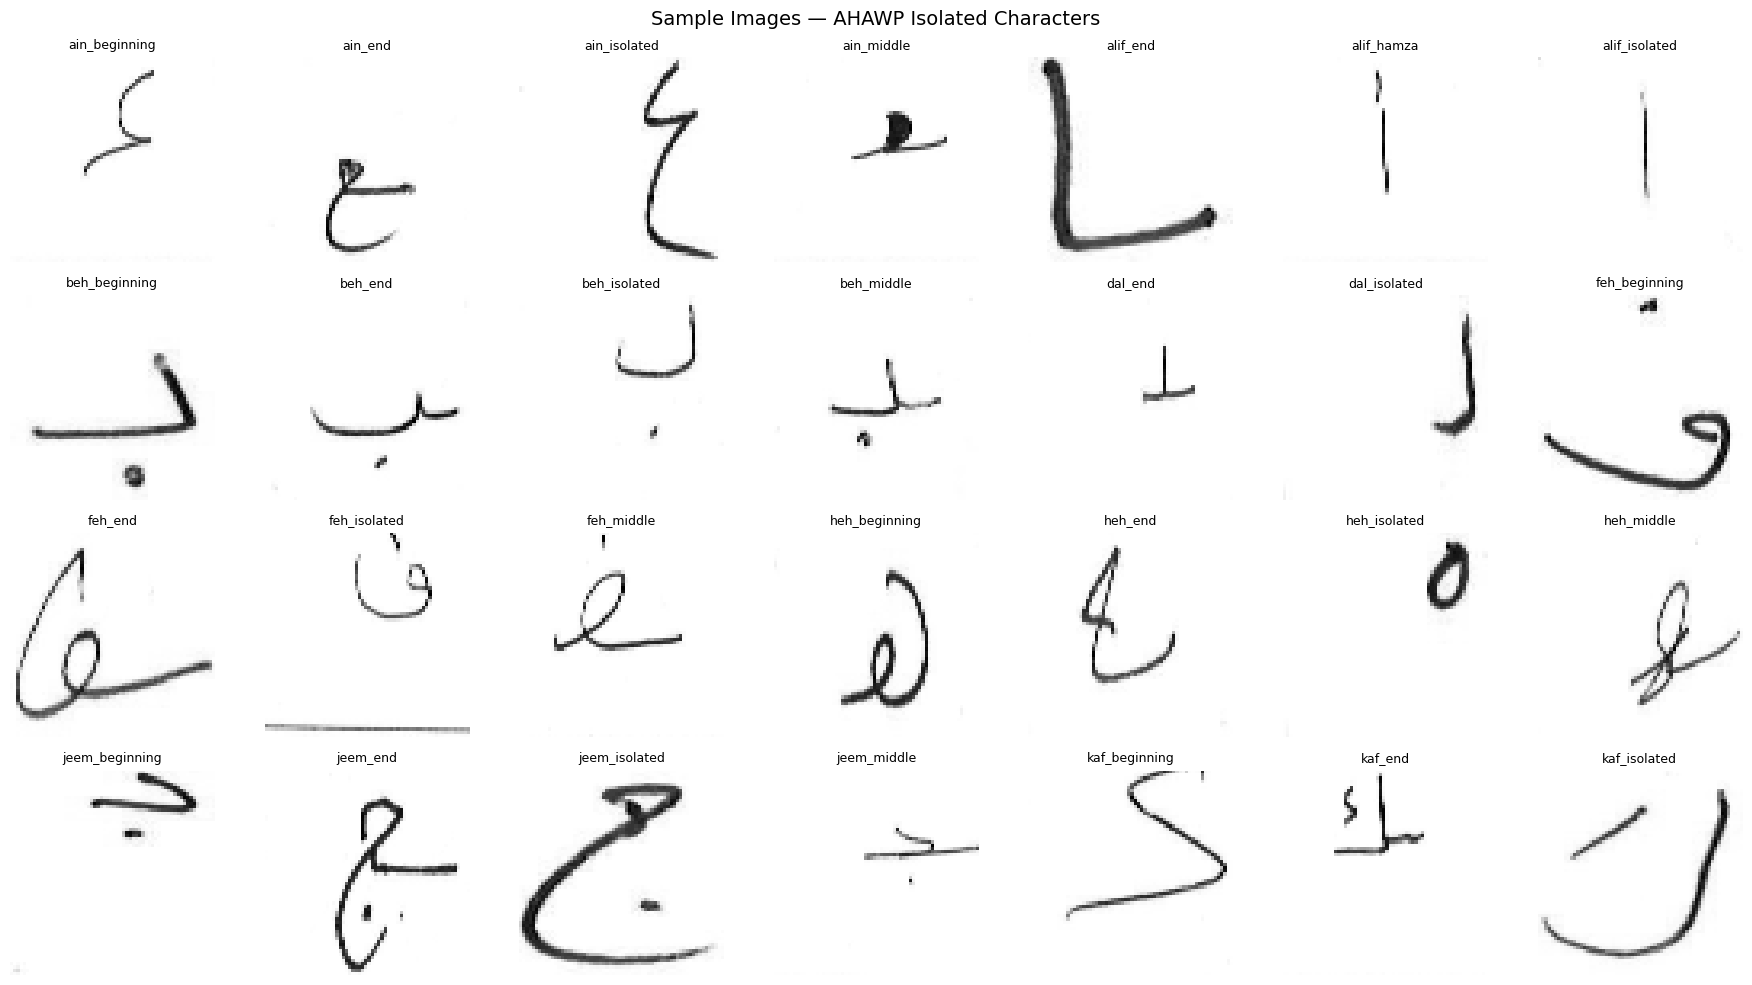

In [24]:
# Visualise sample images per class
fig, axes = plt.subplots(4, 7, figsize=(18, 10))
for ax, label in zip(axes.ravel(), ARABIC_LABELS):
    idx = np.where(y_all == label)[0]
    if len(idx) == 0:
        ax.axis('off'); continue
    sample = X_all[np.random.choice(idx)].squeeze()
    ax.imshow(sample, cmap='gray')
    ax.set_title(label, fontsize=9)
    ax.axis('off')
plt.suptitle("Sample Images — AHAWP Isolated Characters", fontsize=14)
plt.tight_layout()
plt.show()

---
## 3. CNN Training — Isolated Arabic Character Classifier

We offer **two CNN options**:
- **Option A — Custom CNN**: A clean, deeper architecture with residual-style skip connections
- **Option B — MobileNetV2 Transfer Learning**: Faster, higher accuracy, recommended

In [25]:
# Data Augmentation (only on training set)
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    shear_range=0.1,
    fill_mode='nearest'
)
# For grayscale we need to expand to 3 channels for MobileNet
# Helper to expand dims during flow
def expand_channel(X):
    return np.concatenate([X, X, X], axis=-1)  # (N,H,W,1) → (N,H,W,3)

X_train_3ch = expand_channel(X_train)
X_val_3ch   = expand_channel(X_val)
X_test_3ch  = expand_channel(X_test)

In [26]:
# ═══════════════════════════════════════════
# Option A — Custom CNN
# ═══════════════════════════════════════════
def build_custom_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 1), num_classes=NUM_CLASSES):
    """
    Deeper custom CNN with BatchNorm, Dropout, and L2 regularisation.
    Improvements over original notebook:
      - Grayscale input (1 channel instead of 3) — reduces parameters
      - 3 conv blocks instead of 2
      - GlobalAveragePooling instead of Flatten — fewer params, less overfitting
      - Two Dense heads with progressive dropout
    """
    inp = Input(shape=input_shape)

    # Block 1
    x = Conv2D(32, (3,3), padding='same', kernel_regularizer=l1_l2(1e-4, 1e-4))(inp)
    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = Conv2D(32, (3,3), padding='same', kernel_regularizer=l1_l2(1e-4, 1e-4))(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = MaxPool2D(2, 2)(x)
    x = Dropout(0.25)(x)

    # Block 2
    x = Conv2D(64, (3,3), padding='same', kernel_regularizer=l1_l2(1e-4, 1e-4))(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = Conv2D(64, (3,3), padding='same', kernel_regularizer=l1_l2(1e-4, 1e-4))(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = MaxPool2D(2, 2)(x)
    x = Dropout(0.25)(x)

    # Block 3
    x = Conv2D(128, (3,3), padding='same', kernel_regularizer=l1_l2(1e-4, 1e-4))(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = Conv2D(128, (3,3), padding='same', kernel_regularizer=l1_l2(1e-4, 1e-4))(x)
    x = BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = MaxPool2D(2, 2)(x)
    x = Dropout(0.3)(x)

    # Head
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu', kernel_regularizer=l1_l2(1e-4, 1e-4))(x)
    x = Dropout(0.5)(x)
    out = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inp, outputs=out, name='CustomCNN_Arabic')
    return model

model_custom = build_custom_cnn()
model_custom.summary()

Model: "CustomCNN_Arabic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 337,953 (1.29 MB)

 Trainable params: 337,057 (1.29 MB)

 Non-trainable params: 896 (3.50 KB)

In [27]:
# ═══════════════════════════════════════════
# Option B — MobileNetV2 Transfer Learning (recommended)
# ═══════════════════════════════════════════
def build_mobilenet_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """
    Transfer learning with MobileNetV2 pretrained on ImageNet.
    We freeze the base layers first, then fine-tune.
    """
    base = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False  # Freeze initially

    inp = Input(shape=input_shape)
    x = base(inp, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.4)(x)
    out = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inp, outputs=out, name='MobileNetV2_Arabic')
    return model, base

model_mobile, base_model = build_mobilenet_model()
model_mobile.summary()

C:\Users\hagar\AppData\Local\Temp\ipykernel_17592\2396012203.py:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = MobileNetV2(


Model: "MobileNetV2_Arabic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 65)             │        16,705 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,602,625 (9.93 MB)

 Trainable params: 344,641 (1.31 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [28]:
# ─────────────────────────────────────────
# Choose which model to train
# ─────────────────────────────────────────
USE_MOBILENET = True   # Set False to use custom CNN

if USE_MOBILENET:
    model = model_mobile
    X_tr, X_v, X_te = X_train_3ch, X_val_3ch, X_test_3ch
    INPUT_CHANNELS = 3
else:
    model = model_custom
    X_tr, X_v, X_te = X_train, X_val, X_test
    INPUT_CHANNELS = 1

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_arabic_cnn.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

In [29]:
# ─── Phase 1: Train head only (frozen base) ───
print("Phase 1: Training head with frozen base...")
history_phase1 = model.fit(
    datagen.flow(X_tr, y_train, batch_size=64),
    validation_data=(X_v, y_val),
    epochs=20,
    callbacks=callbacks,
    verbose=1
)

Phase 1: Training head with frozen base...
Epoch 1/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.1256 - loss: 3.6287
Epoch 1: val_accuracy improved from None to 0.35652, saving model to best_arabic_cnn.keras

Epoch 1: finished saving model to best_arabic_cnn.keras
582/582 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.1947 - loss: 3.1722 - val_accuracy: 0.3565 - val_loss: 2.3496 - learning_rate: 0.0010
Epoch 2/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.3119 - loss: 2.5164
Epoch 2: val_accuracy improved from 0.35652 to 0.42005, saving model to best_arabic_cnn.keras

Epoch 2: finished saving model to best_arabic_cnn.keras
582/582 ━━━━━━━━━━━━━━━━━━━━ 66s 113ms/step - accuracy: 0.3244 - loss: 2.4484 - val_accuracy: 0.4201 - val_loss: 2.0488 - learning_rate: 0.0010
Epoch 3/20
582/582 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.3607 - loss: 2.2702
Epoch 3: val_accuracy improved from 0.42005 to 0.45376, saving model to best_arabic_cnn.keras

Epoch 3: finis

In [30]:
# ─── Phase 2: Fine-tune top layers of base (MobileNet only) ───
if USE_MOBILENET:
    print("Phase 2: Fine-tuning top 30 layers of MobileNetV2...")
    base_model.trainable = True
    # Freeze all except the last 30 layers
    for layer in base_model.layers[:-30]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # Much lower LR
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history_phase2 = model.fit(
        datagen.flow(X_tr, y_train, batch_size=32),
        validation_data=(X_v, y_val),
        epochs=15,
        callbacks=callbacks,
        verbose=1
    )

Phase 2: Fine-tuning top 30 layers of MobileNetV2...
Epoch 1/15
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.0922 - loss: 6.0709
Epoch 1: val_accuracy did not improve from 0.53584
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 108s 86ms/step - accuracy: 0.1143 - loss: 4.7864 - val_accuracy: 0.2491 - val_loss: 2.9632 - learning_rate: 1.0000e-05
Epoch 2/15
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.1753 - loss: 3.3500
Epoch 2: val_accuracy did not improve from 0.53584
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 105s 90ms/step - accuracy: 0.1894 - loss: 3.2195 - val_accuracy: 0.3033 - val_loss: 2.5422 - learning_rate: 1.0000e-05
Epoch 3/15
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.2401 - loss: 2.8896
Epoch 3: val_accuracy did not improve from 0.53584
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 93s 80ms/step - accuracy: 0.2566 - loss: 2.7953 - val_accuracy: 0.3717 - val_loss: 2.2054 - learning_rate: 1.0000e-05
Epoch 4/15
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.2982 - lo

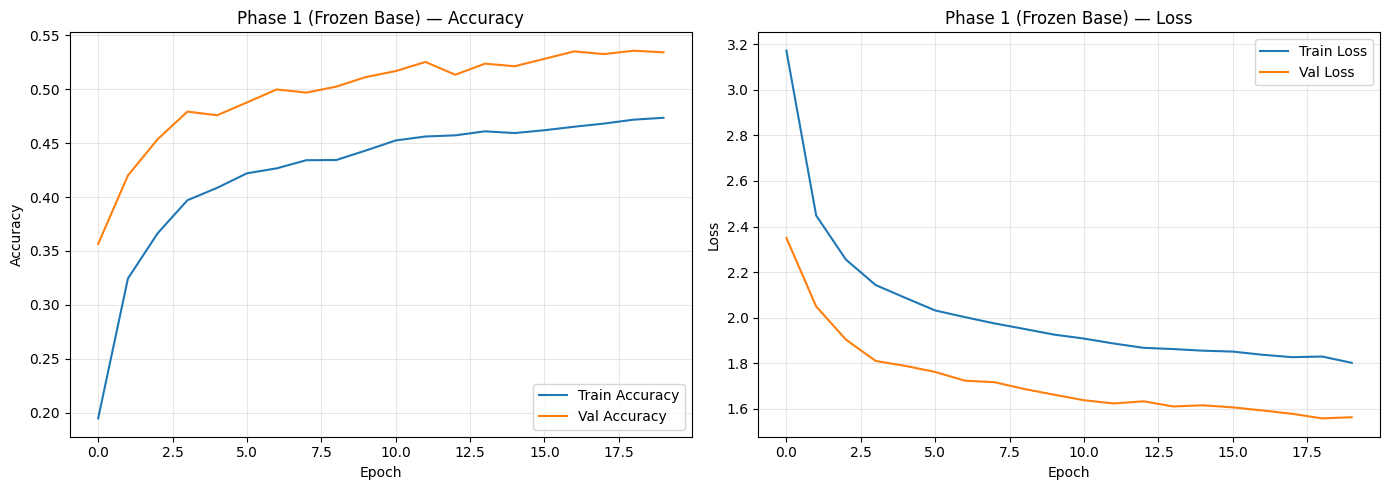

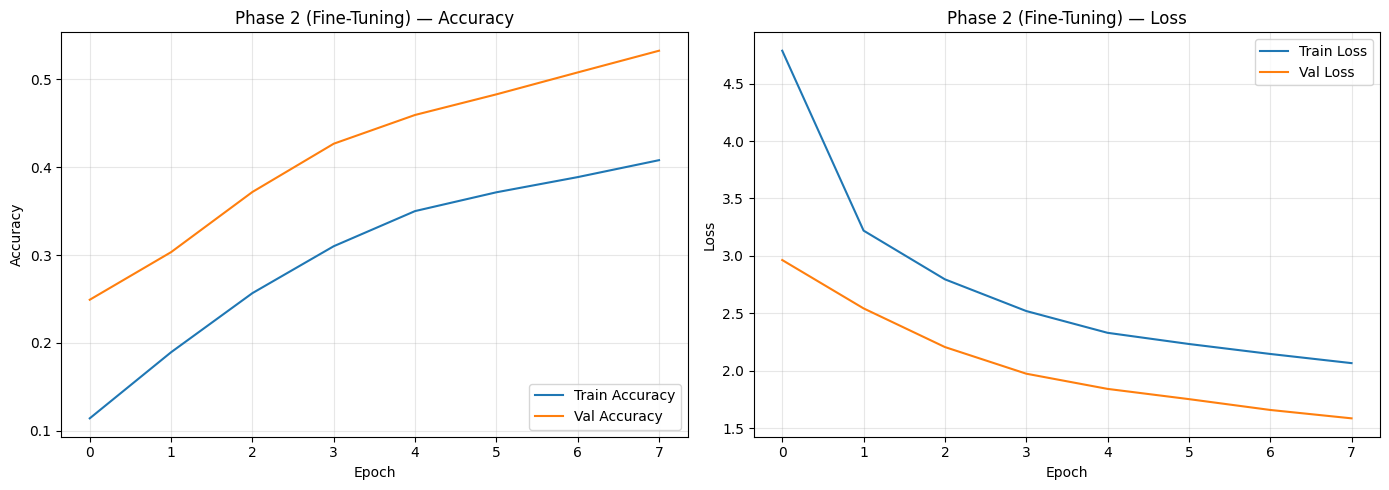

In [31]:
# Plot training history
def plot_history(history, title='Training History'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    hist = history.history

    axes[0].plot(hist['accuracy'], label='Train Accuracy')
    axes[0].plot(hist['val_accuracy'], label='Val Accuracy')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(loc='lower right')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(hist['loss'], label='Train Loss')
    axes[1].plot(hist['val_loss'], label='Val Loss')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history_phase1, 'Phase 1 (Frozen Base)')
if USE_MOBILENET:
    plot_history(history_phase2, 'Phase 2 (Fine-Tuning)')

In [32]:
# Evaluate on test set
loss, acc = model.evaluate(X_te, y_test, verbose=0)
print(f"\n{'='*40}")
print(f"Test Accuracy : {acc:.4f} ({acc*100:.2f}%)")
print(f"Test Loss     : {loss:.4f}")
print(f"{'='*40}")

# Classification report
y_pred = np.argmax(model.predict(X_te), axis=1)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=ARABIC_LABELS))


Test Accuracy : 0.2449 (24.49%)
Test Loss     : 2.9435
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step

Classification Report:
                precision    recall  f1-score   support

 ain_beginning       0.21      0.09      0.12       123
       ain_end       0.21      0.50      0.29       123
  ain_isolated       0.50      0.33      0.40       123
    ain_middle       0.15      0.27      0.19       123
      alif_end       0.28      0.35      0.31       123
    alif_hamza       0.28      0.32      0.30       123
 alif_isolated       0.50      0.43      0.46       123
 beh_beginning       0.31      0.15      0.20       123
       beh_end       0.20      0.23      0.21       123
  beh_isolated       0.27      0.35      0.31       123
    beh_middle       0.18      0.30      0.23       123
       dal_end       0.11      0.08      0.09       123
  dal_isolated       0.18      0.10      0.13       123
 feh_beginning       0.14      0.07      0.10       121
       feh_end       0.12      0.06  

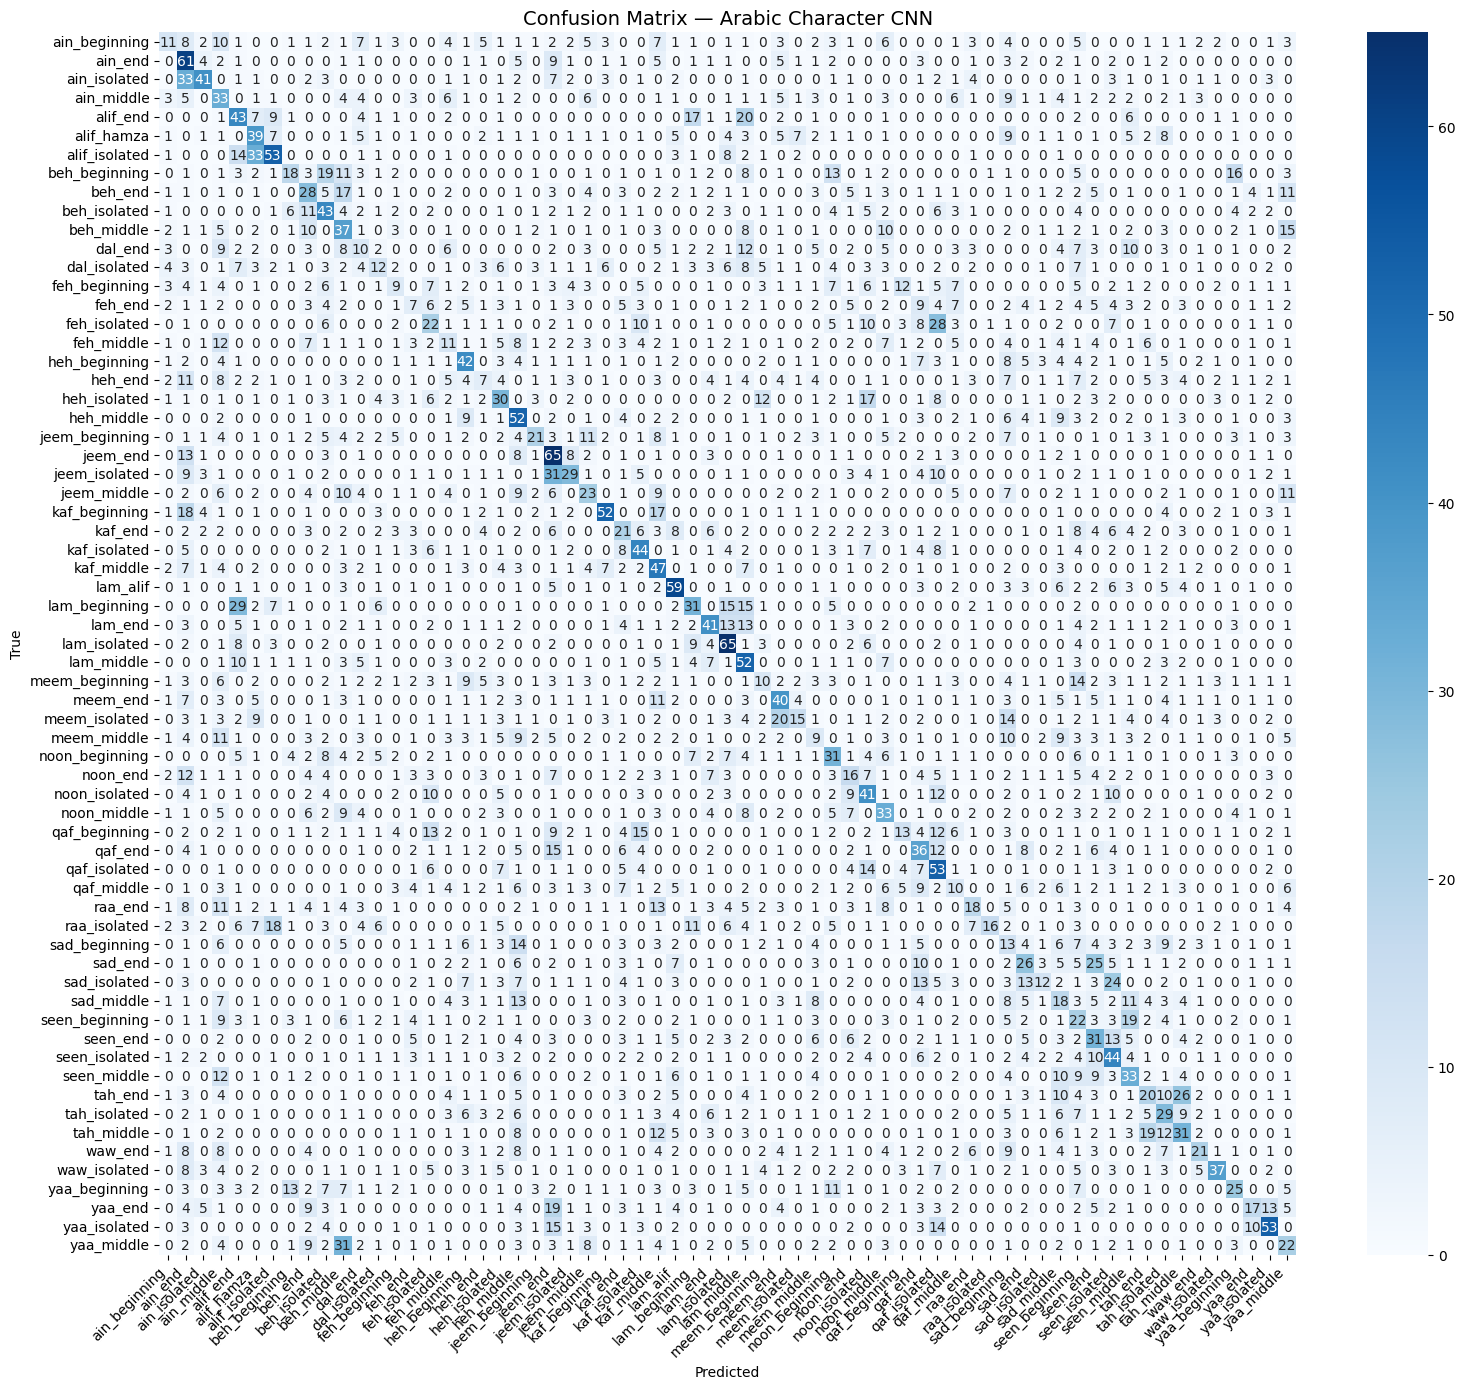


Model saved as arabic_cnn_final.keras


In [33]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ARABIC_LABELS, yticklabels=ARABIC_LABELS)
plt.title('Confusion Matrix — Arabic Character CNN', fontsize=14)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Save model
model.save('arabic_cnn_final.keras')
print("\nModel saved as arabic_cnn_final.keras")

---
## 4. YOLOv8 Training — Character Detection in Cursive Arabic Words

YOLOv8 will detect bounding boxes around each character segment within a cursive word image.

### Why YOLO instead of simple segmentation?
Arabic cursive script is complex — characters overlap, share baseline strokes, and diacritics float above/below. YOLO handles this naturally with overlapping box predictions.

### Annotation format (YOLO txt):
```
<class_id>  <x_center>  <y_center>  <width>  <height>   ← all normalized 0-1
```

In [34]:
import numpy as np
classes = np.load("label_classes.npy", allow_pickle=True)
print(f"Total: {len(classes)}")
print(list(classes))

Total: 65
[np.str_('ain_beginning'), np.str_('ain_end'), np.str_('ain_isolated'), np.str_('ain_middle'), np.str_('alif_end'), np.str_('alif_hamza'), np.str_('alif_isolated'), np.str_('beh_beginning'), np.str_('beh_end'), np.str_('beh_isolated'), np.str_('beh_middle'), np.str_('dal_end'), np.str_('dal_isolated'), np.str_('feh_beginning'), np.str_('feh_end'), np.str_('feh_isolated'), np.str_('feh_middle'), np.str_('heh_beginning'), np.str_('heh_end'), np.str_('heh_isolated'), np.str_('heh_middle'), np.str_('jeem_beginning'), np.str_('jeem_end'), np.str_('jeem_isolated'), np.str_('jeem_middle'), np.str_('kaf_beginning'), np.str_('kaf_end'), np.str_('kaf_isolated'), np.str_('kaf_middle'), np.str_('lam_alif'), np.str_('lam_beginning'), np.str_('lam_end'), np.str_('lam_isolated'), np.str_('lam_middle'), np.str_('meem_beginning'), np.str_('meem_end'), np.str_('meem_isolated'), np.str_('meem_middle'), np.str_('noon_beginning'), np.str_('noon_end'), np.str_('noon_isolated'), np.str_('noon_middl

In [36]:
import shutil
from pathlib import Path

SRC  = Path(r"F:\bach\Arabic-Handwritten-Characters-Recognition-using-CNN\isolated_words_per_user")
DEST = Path(r"F:\bach\Arabic-Handwritten-Characters-Recognition-using-CNN\label_batch")
DEST.mkdir(exist_ok=True)

count = 0
for user_folder in sorted(SRC.iterdir()):
    for img in sorted(user_folder.glob("*.png")):
        shutil.copy(img, DEST / img.name)
        count += 1
        if count >= 100:   # start with 100 images
            break
    if count >= 100:
        break

print(f"Copied {count} images to {DEST}")

Copied 100 images to F:\bach\Arabic-Handwritten-Characters-Recognition-using-CNN\label_batch


In [ ]:
from pathlib import Path

label_dir = Path(r"F:\bach\Arabic-Handwritten-Characters-Recognition-using-CNN\my_dataset\train\labels")

# Read all unique class IDs used
class_ids = set()
for txt in label_dir.glob("*.txt"):
    for line in txt.read_text().splitlines():
        if line.strip():
            class_ids.add(int(line.split()[0]))

print("Class IDs found:", sorted(class_ids))
print("Total unique classes:", len(class_ids))

# Also show a sample label file
sample = list(label_dir.glob("*.txt"))[0]
print(f"\nSample file: {sample.name}")
print(sample.read_text())

In [37]:
# ─────────────────────────────────────────
# 4A. Prepare YOLO dataset structure
# ─────────────────────────────────────────
# Expected AHAWP word annotation format varies by version.
# This code assumes you have annotations in either:
#   (a) YOLO .txt format already, or
#   (b) AHAWP XML/CSV bounding boxes (converted below)

YOLO_DATASET_DIR = Path("yolo_arabic_dataset")

for split in ['train', 'val', 'test']:
    (YOLO_DATASET_DIR / split / 'images').mkdir(parents=True, exist_ok=True)
    (YOLO_DATASET_DIR / split / 'labels').mkdir(parents=True, exist_ok=True)

print("YOLO dataset directory structure created.")
print("\nExpected structure:")
print("yolo_arabic_dataset/")
print("  ├── train/images/   ← word images")
print("  ├── train/labels/   ← YOLO .txt annotations")
print("  ├── val/images/")
print("  ├── val/labels/")
print("  ├── test/images/")
print("  └── test/labels/")

YOLO dataset directory structure created.

Expected structure:
yolo_arabic_dataset/
  ├── train/images/   ← word images
  ├── train/labels/   ← YOLO .txt annotations
  ├── val/images/
  ├── val/labels/
  ├── test/images/
  └── test/labels/


In [38]:
# ─────────────────────────────────────────
# 4B. Convert AHAWP annotations to YOLO format
#     (Adjust for your specific annotation file format)
# ─────────────────────────────────────────

def convert_ahawp_annotation_to_yolo(annotation_file, image_dir, output_dir, split='train'):
    """
    Convert AHAWP bounding box annotations to YOLO format.

    AHAWP annotation CSV expected columns:
        image_name, letter, x1, y1, x2, y2

    Outputs YOLO .txt files: class_id x_c y_c w h (all normalized)
    """
    df = pd.read_csv(annotation_file)
    img_out = YOLO_DATASET_DIR / split / 'images'
    lbl_out = YOLO_DATASET_DIR / split / 'labels'

    for img_name, group in tqdm(df.groupby('image_name'), desc=f'Converting {split}'):
        img_path = Path(image_dir) / img_name
        if not img_path.exists():
            continue

        img = cv2.imread(str(img_path))
        H, W = img.shape[:2]

        # Copy image
        shutil.copy(img_path, img_out / img_name)

        # Write YOLO labels
        label_file = lbl_out / (Path(img_name).stem + '.txt')
        with open(label_file, 'w') as f:
            for _, row in group.iterrows():
                letter = row['letter'].lower()
                if letter not in ARABIC_LABELS:
                    continue
                class_id = ARABIC_LABELS.index(letter)

                x1, y1, x2, y2 = row['x1'], row['y1'], row['x2'], row['y2']
                x_c = ((x1 + x2) / 2) / W
                y_c = ((y1 + y2) / 2) / H
                bw  = (x2 - x1) / W
                bh  = (y2 - y1) / H

                # Clamp to [0, 1]
                x_c, y_c = np.clip(x_c, 0, 1), np.clip(y_c, 0, 1)
                bw, bh   = np.clip(bw, 0, 1), np.clip(bh, 0, 1)

                f.write(f"{class_id} {x_c:.6f} {y_c:.6f} {bw:.6f} {bh:.6f}\n")

# Example usage:
# convert_ahawp_annotation_to_yolo(
#     annotation_file='ahawp/annotations_train.csv',
#     image_dir='ahawp/words/train',
#     output_dir=YOLO_DATASET_DIR,
#     split='train'
# )

print("Annotation converter defined.")
print("Call convert_ahawp_annotation_to_yolo() with your actual annotation paths.")

Annotation converter defined.
Call convert_ahawp_annotation_to_yolo() with your actual annotation paths.


In [43]:
import os
# Check where your notebook is running from
print(os.getcwd())

f:\bach\Arabic-Handwritten-Characters-Recognition-using-CNN


In [47]:
import numpy as np

classes = [
    'ain_beginning', 'ain_end', 'ain_isolated', 'ain_middle',
    'alif_end', 'alif_hamza', 'alif_isolated',
    'beh_beginning', 'beh_end', 'beh_isolated', 'beh_middle',
    'dal_end', 'dal_isolated',
    'feh_beginning', 'feh_end', 'feh_isolated', 'feh_middle',
    'heh_beginning', 'heh_end', 'heh_isolated', 'heh_middle',
    'jeem_beginning', 'jeem_end', 'jeem_isolated', 'jeem_middle',
    'kaf_beginning', 'kaf_end', 'kaf_isolated', 'kaf_middle',
    'lam_alif', 'lam_beginning', 'lam_end', 'lam_isolated', 'lam_middle',
    'meem_beginning', 'meem_end', 'meem_isolated', 'meem_middle',
    'noon_beginning', 'noon_end', 'noon_isolated', 'noon_middle',
    'qaf_beginning', 'qaf_end', 'qaf_isolated', 'qaf_middle',
    'raa_end', 'raa_isolated',
    'sad_beginning', 'sad_end', 'sad_isolated', 'sad_middle',
    'seen_beginning', 'seen_end', 'seen_isolated', 'seen_middle',
    'tah_end', 'tah_isolated', 'tah_middle',
    'waw_end', 'waw_isolated',
    'yaa_beginning', 'yaa_end', 'yaa_isolated', 'yaa_middle'
]

np.save("label_classes.npy", np.array(classes))
print(f"Saved {len(classes)} classes")

Saved 65 classes


In [48]:
import yaml
import numpy as np

classes = [str(c) for c in np.load(
    "label_classes.npy",
    allow_pickle=True
)]

config = {
    'path': 'F:/bach/Arabic-Handwritten-Characters-Recognition-using-CNN/yolo_dataset',
    'train': 'train/images',
    'val':   'val/images',
    'nc':    int(len(classes)),
    'names': classes
}

out = r"F:\bach\Arabic-Handwritten-Characters-Recognition-using-CNN\yolo_dataset\data.yaml"
with open(out, 'w') as f:
    yaml.dump(config, f, default_flow_style=False, allow_unicode=True)

print("Done")
print(open(out).read())

Done
names:
- ain_beginning
- ain_end
- ain_isolated
- ain_middle
- alif_end
- alif_hamza
- alif_isolated
- beh_beginning
- beh_end
- beh_isolated
- beh_middle
- dal_end
- dal_isolated
- feh_beginning
- feh_end
- feh_isolated
- feh_middle
- heh_beginning
- heh_end
- heh_isolated
- heh_middle
- jeem_beginning
- jeem_end
- jeem_isolated
- jeem_middle
- kaf_beginning
- kaf_end
- kaf_isolated
- kaf_middle
- lam_alif
- lam_beginning
- lam_end
- lam_isolated
- lam_middle
- meem_beginning
- meem_end
- meem_isolated
- meem_middle
- noon_beginning
- noon_end
- noon_isolated
- noon_middle
- qaf_beginning
- qaf_end
- qaf_isolated
- qaf_middle
- raa_end
- raa_isolated
- sad_beginning
- sad_end
- sad_isolated
- sad_middle
- seen_beginning
- seen_end
- seen_isolated
- seen_middle
- tah_end
- tah_isolated
- tah_middle
- waw_end
- waw_isolated
- yaa_beginning
- yaa_end
- yaa_isolated
- yaa_middle
nc: 65
path: F:/bach/Arabic-Handwritten-Characters-Recognition-using-CNN/yolo_dataset
train: train/images


In [54]:
import os
print("Working directory:", os.getcwd())
print("\nFolders here:")
for item in os.listdir("."):
    print(" ", item)

Working directory: f:\bach\Arabic-Handwritten-Characters-Recognition-using-CNN

Folders here:
  .git
  .ipynb_checkpoints
  ambiguous_words.1.html
  ambiguous_words.exe
  Arabic Handwritten Alphabets, Words and Paragraphs Per User (AHAWP)
  arabic-chars-mnist
  ArabicCursiveRecognition.ipynb
  ArabicHandwrittenCharacters.ipynb
  ArabicHandwrittenWords.ipynb
  arabic_cnn_final.keras
  arabic_crnn_model.keras
  arabic_letters_model.keras
  arabic_ocr.py
  arabic_ocr_dataset
  best_arabic_cnn.keras
  cnn_per_user.keras
  dataset
  doc
  isolated_alphabets_per_alphabet
  isolated_alphabets_per_user
  isolated_words_per_user
  label_batch
  label_classes.npy
  libfribidi-0.dll
  prelabels.json
  prelabel_words.py
  Presentation.pdf
  processed_temp.png
  README.md
  runs
  tessdata
  tesseract-uninstall.exe
  tesseract.1.html
  tesseract.exe
  test_letter.png
  text2image.1.html
  text2image.exe
  unicharambigs.5.html
  unicharset.5.html
  unicharset_extractor.1.html
  unicharset_extractor.

In [67]:
# ─────────────────────────────────────────
# 4D. Train YOLOv8 Character Detector
# ─────────────────────────────────────────
# Model options: yolov8n (nano/fastest) → yolov8s → yolov8m → yolov8l → yolov8x (largest)
# For Arabic characters in document images, yolov8s is a good balance.

config_path = "yolo_dataset/data.yaml"

yolo_model = YOLO('yolov8s.pt')
yolo_results = yolo_model.train(
    data=config_path,
    epochs=100,
    imgsz=640,
    batch=8,
    patience=15,
    device='cpu',
    project='arabic_yolo',
    name='char_detector',
    exist_ok=True,
    degrees=5.0,
    translate=0.1,
    scale=0.3,
    shear=3.0,
    flipud=0.0,
    fliplr=0.0,
    mosaic=0.5,
    mixup=0.1,
    hsv_h=0.015,
    hsv_s=0.3,
    hsv_v=0.3,
)

print("\nYOLO training complete!")
print(f"Best weights saved at: arabic_yolo/char_detector/weights/best.pt")

New https://pypi.org/project/ultralytics/8.4.24 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.23  Python-3.11.0 torch-2.10.0+cpu CPU (Intel Core i7-10750H 2.60GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/data.yaml, degrees=5.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.3, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=char_detector, nbs=6

In [57]:
# Validate YOLO model
yolo_val = yolo_model.val(data=str(config_path))
print(f"\nmAP@0.5     : {yolo_val.box.map50:.4f}")
print(f"mAP@0.5:0.95: {yolo_val.box.map:.4f}")

Ultralytics 8.4.23  Python-3.11.0 torch-2.10.0+cpu CPU (Intel Core i7-10750H 2.60GHz)
Model summary (fused): 73 layers, 11,150,739 parameters, 0 gradients, 28.6 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 102.356.7 MB/s, size: 7.3 KB)
val: Scanning F:\bach\Arabic-Handwritten-Characters-Recognition-using-CNN\yolo_dataset\val\labels.cache... 10 images, 0 backgrounds, 9 corrupt: 100% ━━━━━━━━━━━━ 10/10  0.0s
val: F:\bach\Arabic-Handwritten-Characters-Recognition-using-CNN\yolo_dataset\val\images\1e247a43-user001_shateerah_034.png: ignoring corrupt image/label: Label class 81 exceeds dataset class count 65. Possible class labels are 0-64
val: F:\bach\Arabic-Handwritten-Characters-Recognition-using-CNN\yolo_dataset\val\images\21696f68-user001_abjadiyah_031.png: ignoring corrupt image/label: Label class 92 exceeds dataset class count 65. Possible class labels are 0-64
val: F:\bach\Arabic-Handwritten-Characters-Recognition-using-CNN\yolo_dataset\val\images\44acd38a-user001_qashtah_

---
## 5. Full Inference Pipeline — Cursive Word Recognition

```
Input word image
    │
    ▼
YOLOv8 → bounding boxes + class predictions
    │
    ▼
Sort boxes right-to-left (Arabic reads RTL)
    │
    ▼
For each box → crop → CNN classifier → confirm/override
    │
    ▼
Assemble character sequence → word output
```

In [61]:
from pathlib import Path
import os

# Check if YOLO training has run at all
print("arabic_yolo exists:", Path("arabic_yolo").exists())

# Check yolo_dataset structure
print("\nyolo_dataset contents:")
for f in Path("yolo_dataset").rglob("*"):
    print(" ", f)

arabic_yolo exists: False

yolo_dataset contents:
  yolo_dataset\data.yaml
  yolo_dataset\train
  yolo_dataset\val
  yolo_dataset\train\images
  yolo_dataset\train\labels
  yolo_dataset\train\labels.cache
  yolo_dataset\train\images\1e247a43-user001_shateerah_034.png
  yolo_dataset\train\images\21696f68-user001_abjadiyah_031.png
  yolo_dataset\train\images\44acd38a-user001_qashtah_023.png
  yolo_dataset\train\images\5e09e0ea-user001_azan_001.png
  yolo_dataset\train\images\634b419e-user001_mehras_050.png
  yolo_dataset\train\images\6359437d-user001_sakhar_019.png
  yolo_dataset\train\images\7fbca7f0-user001_mustadhafeen_026.png
  yolo_dataset\train\images\9054b4ae-user001_ghazaal_001.png
  yolo_dataset\train\images\c04c4bc8-user001_ghaleez_013.png
  yolo_dataset\train\images\d3eaa36b-user001_fasayakfeekahum_042.png
  yolo_dataset\train\labels\1e247a43-user001_shateerah_034.txt
  yolo_dataset\train\labels\21696f68-user001_abjadiyah_031.txt
  yolo_dataset\train\labels\44acd38a-user001_qa

In [65]:
from ultralytics import YOLO

yolo_model = YOLO('yolov8s.pt')
yolo_results = yolo_model.train(
    data='yolo_dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=2,        # very small batch for 10 images
    patience=20,
    device='cpu',
    project='arabic_yolo',
    name='char_detector',
    exist_ok=True,
    degrees=5.0,
    translate=0.1,
    scale=0.3,
    shear=3.0,
    flipud=0.0,
    fliplr=0.0,
    mosaic=0.0,     # disable mosaic with so few images
    mixup=0.0,      # disable mixup with so few images
    hsv_h=0.015,
    hsv_s=0.3,
    hsv_v=0.3,
)

New https://pypi.org/project/ultralytics/8.4.24 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.23  Python-3.11.0 torch-2.10.0+cpu CPU (Intel Core i7-10750H 2.60GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_dataset/data.yaml, degrees=5.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.3, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.0, multi_scale=0.0, name=char_detector, nbs=64

In [64]:
import shutil
from pathlib import Path

train_imgs = list(Path("yolo_dataset/train/images").glob("*.png"))
print(f"Train images: {len(train_imgs)}")

# Copy a few to val so YOLO doesn't crash
val_img_dir = Path("yolo_dataset/val/images")
val_lbl_dir = Path("yolo_dataset/val/labels")
val_img_dir.mkdir(parents=True, exist_ok=True)
val_lbl_dir.mkdir(parents=True, exist_ok=True)

# Use 2 images for val, 8 for train
for img in train_imgs[:2]:
    shutil.copy(img, val_img_dir / img.name)
    lbl = Path("yolo_dataset/train/labels") / img.with_suffix('.txt').name
    if lbl.exists():
        shutil.copy(lbl, val_lbl_dir / lbl.name)

print("Val images:", len(list(val_img_dir.glob("*.png"))))

Train images: 10
Val images: 10


In [72]:
from pathlib import Path
for f in Path("arabic_yolo").rglob("*"):
    print(f)

In [84]:
CNN_MODEL_PATH  = 'arabic_cnn_final.keras'
YOLO_MODEL_PATH = r'F:\bach\Arabic-Handwritten-Characters-Recognition-using-CNN\runs\detect\arabic_yolo\char_detector\weights\best.pt'

cnn_model     = tf.keras.models.load_model(CNN_MODEL_PATH)
yolo_detector = YOLO(YOLO_MODEL_PATH)

label_classes = np.load('label_classes.npy', allow_pickle=True)
print(f"CNN loaded: {CNN_MODEL_PATH}")
print(f"YOLO loaded: {YOLO_MODEL_PATH}")
print(f"Classes: {len(label_classes)}")

CNN loaded: arabic_cnn_final.keras
YOLO loaded: F:\bach\Arabic-Handwritten-Characters-Recognition-using-CNN\runs\detect\arabic_yolo\char_detector\weights\best.pt
Classes: 65


In [85]:
def preprocess_for_cnn(crop_bgr, img_size=IMG_SIZE, use_3ch=USE_MOBILENET):
    """
    Preprocess a cropped character image for CNN inference.
    - Grayscale → threshold → square-pad → resize → normalize
    """
    gray = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2GRAY)
    # Otsu threshold to binarize handwriting
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Find tight bounding box around ink
    coords = cv2.findNonZero(thresh)
    if coords is None:
        return None
    x, y, w, h = cv2.boundingRect(coords)
    roi = thresh[y:y+h, x:x+w]

    # Square pad with 20% margin
    side = int(max(h, w) * 1.2)
    canvas = np.zeros((side, side), dtype='uint8')
    ox, oy = (side - w) // 2, (side - h) // 2
    canvas[oy:oy+h, ox:ox+w] = roi

    # Resize and normalise
    resized = cv2.resize(canvas, (img_size, img_size), interpolation=cv2.INTER_AREA)
    normalized = resized.astype('float32') / 255.0

    if use_3ch:
        normalized = np.stack([normalized] * 3, axis=-1)  # (H,W,3)
    else:
        normalized = normalized[..., np.newaxis]           # (H,W,1)

    return normalized


def recognize_word(image_path, conf_threshold=0.3, use_cnn_override=True):
    """
    Full pipeline: detect characters with YOLO → classify each with CNN.

    Args:
        image_path: path to a cursive Arabic word image
        conf_threshold: minimum YOLO confidence to accept a detection
        use_cnn_override: if True, CNN class overrides YOLO class

    Returns:
        recognized_word: list of character names (right-to-left order)
        annotated_image: image with drawn bounding boxes and labels
    """
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {image_path}")

    H, W = img.shape[:2]
    annotated = img.copy()

    # ── Step 1: YOLO Detection ──────────────────────
    results = yolo_detector(img, conf=conf_threshold, verbose=False)[0]
    boxes = results.boxes

    if len(boxes) == 0:
        print("No characters detected by YOLO.")
        return [], annotated

    detections = []
    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        yolo_class_id  = int(box.cls[0])
        yolo_conf      = float(box.conf[0])
        yolo_label     = ARABIC_LABELS[yolo_class_id]
        detections.append((x1, y1, x2, y2, yolo_label, yolo_conf))

    # ── Step 2: Sort RTL (right-to-left — Arabic direction) ────
    detections.sort(key=lambda d: -d[0])  # sort by x1 descending

    # ── Step 3: CNN Classification per crop ─────────────────
    recognized = []
    for (x1, y1, x2, y2, yolo_label, yolo_conf) in detections:
        # Clamp to image bounds
        x1c, y1c = max(0, x1), max(0, y1)
        x2c, y2c = min(W, x2), min(H, y2)
        crop = img[y1c:y2c, x1c:x2c]

        if crop.size == 0:
            continue

        final_label = yolo_label
        cnn_conf    = yolo_conf

        if use_cnn_override:
            proc = preprocess_for_cnn(crop)
            if proc is not None:
                inp = np.expand_dims(proc, axis=0)
                preds = cnn_model.predict(inp, verbose=0)[0]
                cnn_idx   = np.argmax(preds)
                cnn_conf  = float(preds[cnn_idx])
                final_label = label_classes[cnn_idx]

        recognized.append(final_label)

        # Draw on annotated image
        color = (0, 200, 0)
        cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
        txt = f"{final_label} {cnn_conf:.0%}"
        cv2.putText(annotated, txt, (x1, max(0, y1-6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

    return recognized, annotated


print("Inference pipeline ready.")

Inference pipeline ready.



Detected characters (RTL): [np.str_('jeem_end'), np.str_('jeem_end'), np.str_('heh_isolated'), np.str_('seen_isolated'), np.str_('seen_isolated'), np.str_('seen_isolated'), np.str_('seen_isolated'), np.str_('seen_isolated')]
Word: jeem_end jeem_end heh_isolated seen_isolated seen_isolated seen_isolated seen_isolated seen_isolated


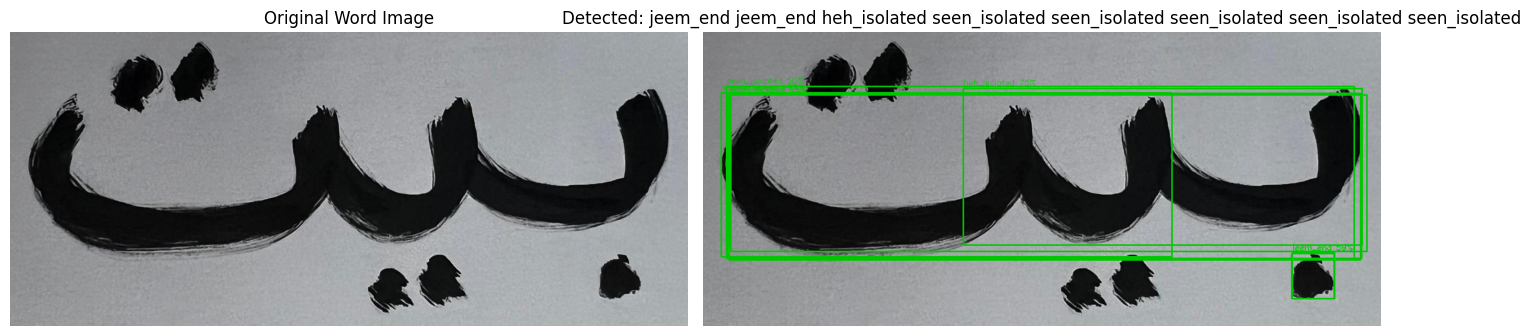

In [86]:
# ─────────────────────────────────────────
# Run inference on a test word image
# ─────────────────────────────────────────
TEST_WORD_IMAGE = 'word_test.png'   # ← Replace with your image path

word_chars, annotated_img = recognize_word(TEST_WORD_IMAGE, conf_threshold=0.3)

# Display results
print(f"\n{'='*40}")
print(f"Detected characters (RTL): {word_chars}")
print(f"Word: {' '.join(word_chars)}")
print(f"{'='*40}")

# Show annotated image
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
original = cv2.cvtColor(cv2.imread(TEST_WORD_IMAGE), cv2.COLOR_BGR2RGB)
annotated_rgb = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

axes[0].imshow(original); axes[0].set_title('Original Word Image'); axes[0].axis('off')
axes[1].imshow(annotated_rgb); axes[1].set_title(f'Detected: {" ".join(word_chars)}'); axes[1].axis('off')
plt.tight_layout()
plt.show()

---
## 6. Batch Evaluation on Word-Level Test Set

In [87]:
def evaluate_word_recognition(test_image_dir, ground_truth_csv):
    """
    Evaluate word recognition accuracy.

    ground_truth_csv columns: image_name, true_chars
    true_chars: space-separated letter names in RTL order
    e.g., "beh alef kaf" for the word بك ا
    """
    df = pd.read_csv(ground_truth_csv)
    correct = 0
    total   = 0
    cer_total = 0  # Character Error Rate

    for _, row in tqdm(df.iterrows(), total=len(df), desc='Evaluating'):
        img_path = Path(test_image_dir) / row['image_name']
        true_chars = row['true_chars'].split()

        try:
            pred_chars, _ = recognize_word(img_path, conf_threshold=0.3)
        except Exception as e:
            print(f"Error on {img_path}: {e}")
            continue

        total += 1
        if pred_chars == true_chars:
            correct += 1

        # Character Error Rate (edit distance based)
        from difflib import SequenceMatcher
        sm = SequenceMatcher(None, true_chars, pred_chars)
        cer = 1 - sm.ratio()
        cer_total += cer

    word_acc = correct / total if total > 0 else 0
    avg_cer  = cer_total / total if total > 0 else 0

    print(f"\n{'='*40}")
    print(f"Word Accuracy      : {word_acc:.4f} ({word_acc*100:.2f}%)")
    print(f"Avg Character Error: {avg_cer:.4f} ({avg_cer*100:.2f}%)")
    print(f"Total words        : {total}")
    print(f"{'='*40}")
    return word_acc, avg_cer

# Example:
# evaluate_word_recognition(
#     test_image_dir='ahawp/words/test',
#     ground_truth_csv='ahawp/word_labels_test.csv'
# )

In [88]:
# ─────────────────────────────────────────
# Quick single-image demo with webcam/upload
# ─────────────────────────────────────────
def demo_from_file(image_path):
    """Run the full pipeline and display results interactively."""
    chars, annotated = recognize_word(image_path)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    orig = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
    ann  = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

    axes[0].imshow(orig)
    axes[0].set_title('Input', fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(ann)
    axes[1].set_title(
        f'Detected ({len(chars)} chars): {" → ".join(chars)}',
        fontsize=12
    )
    axes[1].axis('off')

    plt.suptitle('Arabic Cursive Word Recognition', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"\nCharacters (right → left): {chars}")

# demo_from_file('your_word.png')

---
## Summary of Improvements vs. Original Notebook

| Feature | Original Notebook | This Notebook |
|---|---|---|
| Dataset | Arabic MNIST (isolated, 32×32) | AHAWP (richer, multi-writer) |
| Image size | 32×32 | 64×64 |
| CNN architecture | Simple sequential, 2 blocks | 3-block custom CNN **+** MobileNetV2 transfer learning |
| Regularisation | Dropout + L1L2 | Dropout + L1L2 + BatchNorm per block |
| Training strategy | Single phase | Two-phase (frozen → fine-tune) |
| Augmentation | None | Rotation, shift, zoom, shear |
| Callbacks | None | EarlyStopping + ReduceLR + ModelCheckpoint |
| Word recognition | Fixed-segment splitting | **YOLOv8** character detection |
| Reading order | Left-to-right (wrong!) | **Right-to-left** (correct Arabic direction) |
| Evaluation | Accuracy only | Accuracy + CER + Confusion Matrix |
| Preprocessing | Fixed threshold | Otsu + contour-aware padding |
